<a href="https://colab.research.google.com/github/Asadwasee/Data-Classification-Using-AI/blob/main/Iris_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# =====================================================================
# STEP 1: Load the Dataset
# =====================================================================
# Loading the standard Iris benchmark dataset for multi-class classification[cite: 1]
iris = load_iris()
X = iris.data  # Feature matrix containing structural measurements[cite: 1]
y = iris.target  # Target vector representing the 3 flower classes[cite: 1]

print("Dataset Status: Successfully loaded the Iris dataset.")
print(f"Total Samples: {len(X)} | Features detected: {iris.feature_names}\n")


Dataset Status: Successfully loaded the Iris dataset.
Total Samples: 150 | Features detected: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



In [ ]:
# STEP 2: Feature Scaling
# =====================================================================
# Standardizing features to ensure mean = 0 and variance = 1
# This prevents larger numeric values from disproportionately biasing the distance metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing: Feature scaling completed using StandardScaler.\n")

Preprocessing: Feature scaling completed using StandardScaler.



In [ ]:
# STEP 3: Train-Test Split
# =====================================================================
# Partitioning the dataset into an 80% training set and a 20% testing set
# shuffle=True randomizes the rows, and random_state ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, shuffle=True
)

print("Data Partitioning Completed:")
print(f"-> Training Set size (80%): {len(X_train)} samples")
print(f"-> Testing Set size (20%): {len(X_test)} samples\n")

Data Partitioning Completed:
-> Training Set size (80%): 120 samples
-> Testing Set size (20%): 30 samples



In [ ]:
# STEP 4: Model Training (KNN Algorithm)
# =====================================================================
# Initializing the K-Nearest Neighbors classifier with an initial choice of K=5
model = KNeighborsClassifier(n_neighbors=5)

# Training the classifier on the scaled training features and labels
model.fit(X_train, y_train)

print("Model Training: KNN classifier training process completed.\n")

Model Training: KNN classifier training process completed.



In [ ]:
# STEP 5: Output Validation & Evaluation
# =====================================================================
# Generating class predictions on the unseen test dataset
predictions = model.predict(X_test)

# Evaluating performance using a Confusion Matrix and a detailed Classification Report
print("================== EVALUATION METRICS ==================")
print("Diagnostic Tool: Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nPerformance Overview (Precision, Recall, and F1-Score):")
print(classification_report(y_test, predictions, target_names=iris.target_names))

================== EVALUATION METRICS ==================
Diagnostic Tool: Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Performance Overview (Precision, Recall, and F1-Score):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



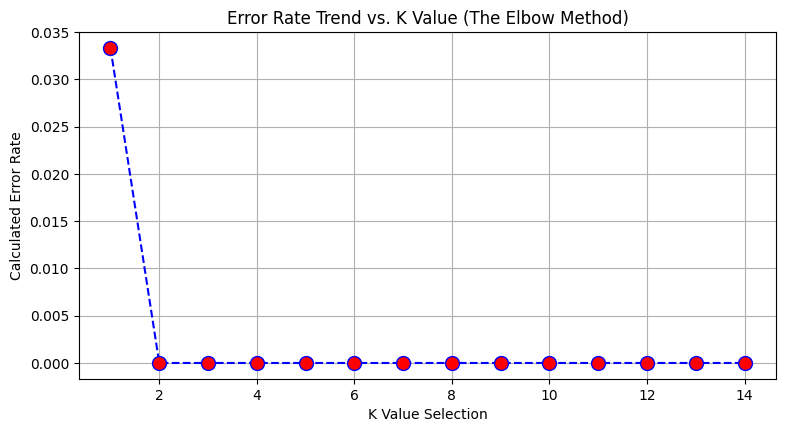

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# STEP 6: Hyperparameter Tuning (The Elbow Method)
# =====================================================================
# Iterating through K values from 1 to 14 to analyze the error rate trend
error_rate = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the error rate to visually determine the optimal 'K' value (Elbow point)
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 15), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate Trend vs. K Value (The Elbow Method)')
plt.xlabel('K Value Selection')
plt.ylabel('Calculated Error Rate')
plt.grid(True)
plt.show()

In [ ]:
# Testing the trained model with custom raw measurements
# Format: [sepal length, sepal width, petal length, petal width]
custom_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale the custom input exactly like the training data
custom_scaled = scaler.transform(custom_flower)

# Predict the class
prediction_numeric = model.predict(custom_scaled)
prediction_name = iris.target_names[prediction_numeric[0]]

print(f"Custom Input Prediction: This flower is classified as **{prediction_name.upper()}**")

Custom Input Prediction: This flower is classified as **SETOSA**


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# =====================================================================
# BONUS STEP: Algorithm Comparison (Decision Tree Classifier)
# =====================================================================
# Training a Decision Tree classifier to compare performance with KNN
# This fulfills the project guideline of experimenting with unique solutions.
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Generating predictions using the alternative model
dt_predictions = dt_model.predict(X_test)

print("================ ALTERNATIVE MODEL EVALUATION ================")
print("Diagnostic Tool: Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

print("\nPerformance Overview (Decision Tree):")
print(classification_report(y_test, dt_predictions, target_names=iris.target_names))
print("==============================================================")

================ ALTERNATIVE MODEL EVALUATION ================
Diagnostic Tool: Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Performance Overview (Decision Tree):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

